In [1]:
import pickle
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
import threading
from datetime import date
from itertools import product
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import nse, kge, mkge, kge_r, kge_beta, kge_alpha, mkge_alpha
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameter_defaults_jablje import (
    jablje_soil_layers,
    jablje_curve_number,
    jablje_readily_evaporable_water,
    jablje_maize_params,
    jablje_optimal_management,
    jablje_initial_cond,
    jablje_groundwater,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "jablje"
MAX_WORKERS = os.cpu_count()

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024)
    if year not in [2017]
]

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_biomass = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")
observed_grain = get_yield_for_comparison(LOCATION, "grain", "A", "N3")

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}

In [5]:
# Parameters to search and their grid values (bounds from Optimization Jablje)
grid_params = {
    #"harvest_index":        np.linspace(0.46, 0.56, 6),
    #"gdd_senescence":       np.linspace(1000, 1150, 5),
    #"gdd_maturity":         np.linspace(1200, 1400, 5),
    "gdd_flowering":        np.linspace(480, 530, 5),
    "gdd_flowering_length": np.linspace(130, 170, 3),
    #"max_canopy_cover":     np.linspace(0.85, 0.95, 5), # zacasno
    "min_rooting_depth":    np.linspace(0.2, 0.4, 3),
    "max_rooting_depth":    np.linspace(0.5, 2.5, 5),
    "ksat":                 np.array([5., 20., 100., 575.]),
    "cgc_gdd":              np.linspace(0.010, 0.015, 5)
}

SOIL_PARAMS = {"ksat"}

param_names = list(grid_params.keys())
grid_combinations = list(product(*grid_params.values()))

grid_shape = " x ".join(str(len(v)) for v in grid_params.values())
print(f"Grid: {grid_shape} = {len(grid_combinations):,} combinations")
print(f"Workers: {MAX_WORKERS}")

Grid: 5 x 3 x 3 x 5 x 4 x 5 = 4,500 combinations
Workers: 11


In [6]:
# Pre-create one working directory per worker to avoid conflicts
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.RAMDISK_DIR / f"grid_jablje_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories: {[str(d) for d in worker_dirs]}")

Worker directories: ['E:/aquacrop/grid_jablje_0', 'E:/aquacrop/grid_jablje_1', 'E:/aquacrop/grid_jablje_2', 'E:/aquacrop/grid_jablje_3', 'E:/aquacrop/grid_jablje_4', 'E:/aquacrop/grid_jablje_5', 'E:/aquacrop/grid_jablje_6', 'E:/aquacrop/grid_jablje_7', 'E:/aquacrop/grid_jablje_8', 'E:/aquacrop/grid_jablje_9', 'E:/aquacrop/grid_jablje_10']


In [7]:
def evaluate_params(param_values):
    """Run one grid point and return parameter values + all scores for both grain and biomass."""
    working_dir = dir_queue.get()
    try:
        params = copy.deepcopy(jablje_maize_params)
        soil_vals = {}
        for name, val in zip(param_names, param_values):
            if name in SOIL_PARAMS:
                soil_vals[name] = float(val)
            else:
                params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        if soil_vals:
            layers = copy.deepcopy(jablje_soil_layers)
            for layer in layers:
                for k, v in soil_vals.items():
                    setattr(layer, k, v)
            current_soil = Soil(
                name=f"{LOCATION} soil",
                description=f"{LOCATION} loamy sand soil",
                soil_layers=layers,
                curve_number=jablje_curve_number,
                readily_evaporable_water=jablje_readily_evaporable_water,
            )
        else:
            current_soil = soil

        crop = Crop(
            name=f"{LOCATION} maize",
            description="grid search",
            params=params,
        )

        simulation = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=current_soil,
            management=jablje_optimal_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            #ground_water=jablje_groundwater,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_metrics = {f"{prefix}_{s}": np.nan
                       for prefix in ("biomass", "grain")
                       for s in ["rmse", "r2", "nse", "kge", "mkge", "kge_r", "kge_beta", "kge_alpha", "mkge_alpha"]}

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return {**dict(zip(param_names, param_values)), **nan_metrics}

        seasonal = results["season"][["Year1", "BioMass", "Y(dry)"]].rename(
            columns={"Year1": "year", "BioMass": "biomass_modeled", "Y(dry)": "grain_modeled"}
        )

        def compute_metrics(observed_df, modeled_col, prefix):
            merged = observed_df.merge(seasonal[["year", modeled_col]], on="year")
            y_obs = merged["yield"].values
            y_mod = merged[modeled_col].values
            return {
                f"{prefix}_rmse":       root_mean_squared_error(y_obs, y_mod),
                f"{prefix}_r2":         r2_score(y_obs, y_mod),
                f"{prefix}_nse":        nse(y_mod, y_obs),
                f"{prefix}_kge":        kge(y_mod, y_obs),
                f"{prefix}_mkge":       mkge(y_mod, y_obs),
                f"{prefix}_kge_r":      kge_r(y_mod, y_obs),
                f"{prefix}_kge_beta":   kge_beta(y_mod, y_obs),
                f"{prefix}_kge_alpha":  kge_alpha(y_mod, y_obs),
                f"{prefix}_mkge_alpha": mkge_alpha(y_mod, y_obs),
            }

        return {
            **dict(zip(param_names, param_values)),
            **compute_metrics(observed_biomass, "biomass_modeled", "biomass"),
            **compute_metrics(observed_grain, "grain_modeled", "grain"),
        }
    finally:
        dir_queue.put(working_dir)

360 simulacij / 1 minuto

In [8]:
total = len(grid_combinations)
results_list = []

print(f"Running {total:,} simulations with {MAX_WORKERS} workers...")
print(f"Approximate running time: {total // 360} min")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(evaluate_params, combo) for combo in grid_combinations]
    for future in as_completed(futures):
        results_list.append(future.result())

results_df = pd.DataFrame(results_list).sort_values("grain_rmse").reset_index(drop=True)
print(f"\nComplete. Failed runs: {results_df['biomass_rmse'].isna().sum()}")

Running 4,500 simulations with 11 workers...
Approximate running time: 12 min
Results successfully parsed


In [9]:
output_path = config.RESULTS_DIR / "grid_search_jablje_8_biomass.pkl"
results_df.to_pickle(output_path)
print(f"Saved {len(results_df):,} rows to {output_path}")

In [10]:
output_path = config.RESULTS_DIR / "grid_search_jablje_8_biomass.pkl"
results_df = pd.read_pickle(output_path)

In [89]:
results_df.sort_values("biomass_nse").reset_index(drop=True)

,gdd_flowering,gdd_flowering_length,min_rooting_depth,max_rooting_depth,ksat,cgc_gdd,biomass_rmse,biomass_r2,biomass_nse,biomass_kge,...,biomass_mkge_alpha,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
0,480.0,130.0,0.2,0.5,5.0,0.0100,13.525573,-8.703487,-8.703487,-0.165669,...,1.624399,7.270925,-11.555618,-11.555618,-0.194761,-0.411327,0.208581,0.260381,0.495944,1.904689
1,480.0,150.0,0.2,0.5,5.0,0.0100,13.401383,-8.526113,-8.526113,-0.165830,...,1.631750,7.197088,-11.301905,-11.301905,-0.191468,-0.411670,0.195337,0.269320,0.511923,1.900797
2,492.5,130.0,0.2,0.5,5.0,0.0100,13.375725,-8.489672,-8.489672,-0.164405,...,1.632956,7.190092,-11.278002,-11.278002,-0.193252,-0.413804,0.190711,0.270290,0.513764,1.900787
3,480.0,170.0,0.2,0.5,5.0,0.0100,13.280128,-8.354510,-8.354510,-0.162188,...,1.638119,7.129467,-11.071825,-11.071825,-0.186067,-0.412128,0.186833,0.277460,0.527296,1.900444
4,492.5,150.0,0.2,0.5,5.0,0.0100,13.257994,-8.323354,-8.323354,-0.161175,...,1.638529,7.121850,-11.046043,-11.046043,-0.188633,-0.413810,0.181212,0.278539,0.528906,1.898855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4495,517.5,170.0,0.2,1.0,575.0,0.0125,4.182970,0.071919,0.071919,-0.063372,...,0.224756,2.165388,-0.113603,-0.113603,0.066671,0.092872,0.449676,0.885106,0.254986,0.288085
4496,530.0,170.0,0.2,1.0,575.0,0.0125,4.181895,0.072396,0.072396,-0.062302,...,0.224376,2.136903,-0.084497,-0.084497,0.068452,0.093267,0.448888,0.891217,0.256882,0.288237
4497,530.0,130.0,0.2,1.0,575.0,0.0125,4.181659,0.072500,0.072500,-0.061061,...,0.226132,2.193694,-0.142907,-0.142907,0.083346,0.113150,0.460407,0.877030,0.269266,0.307020
4498,517.5,150.0,0.2,1.0,575.0,0.0125,4.180826,0.072870,0.072870,-0.060118,...,0.226302,2.197700,-0.147085,-0.147085,0.070617,0.099096,0.452715,0.877785,0.258856,0.294897


In [90]:
best = {}

In [92]:
# Re-run with the best parameter set (lowest RMSE) to get full seasonal results for plotting
results_df.sort_values("biomass_nse").reset_index(drop=True)
best = results_df.iloc[0]

best_params = copy.deepcopy(jablje_maize_params)
best_soil_vals = {}
for name in param_names:
    val = best[name]
    if name in SOIL_PARAMS:
        best_soil_vals[name] = float(val)
    else:
        best_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

if best_soil_vals:
    best_layers = copy.deepcopy(jablje_soil_layers)
    for layer in best_layers:
        for k, v in best_soil_vals.items():
            setattr(layer, k, v)
    best_soil = Soil(
        name=f"{LOCATION} soil",
        description=f"{LOCATION} loamy sand soil",
        soil_layers=best_layers,
        curve_number=jablje_curve_number,
        readily_evaporable_water=jablje_readily_evaporable_water,
    )
else:
    best_soil = soil

best_crop = Crop(
    name=f"{LOCATION} maize (best grid)",
    description="best grid search parameters",
    params=best_params,
)

best_dir = config.RAMDISK_DIR / "grid_jablje_best"
best_dir.mkdir(parents=True, exist_ok=True)

best_simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=best_crop,
    soil=best_soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=weather,
    #ground_water=jablje_groundwater,
    working_dir=best_dir,
    need_daily_output=False,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False,
)

best_results = best_simulation.run()
best_seasonal = best_results["season"]

print(f"RMSE:  {best['grain_rmse']:.4f}")
print(f"R2:    {best['grain_r2']:.4f}")
print(f"NSE:   {best['grain_nse']:.4f}")
print(f"KGE:   {best['grain_kge']:.4f}")
print(f"mKGE:  {best['grain_mkge']:.4f}")

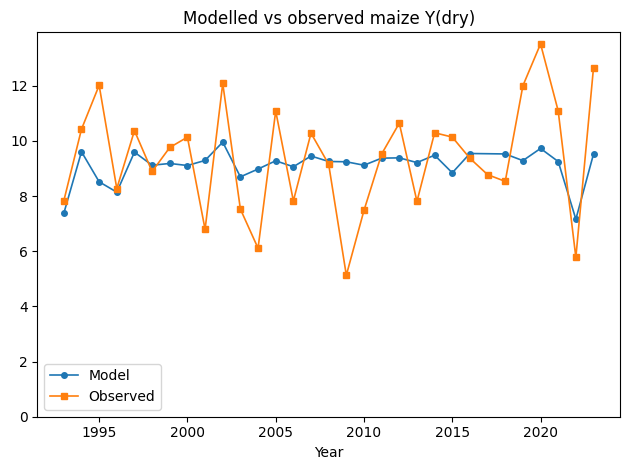

In [93]:
plot_yield_timeseries_comparison(best_seasonal, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)")

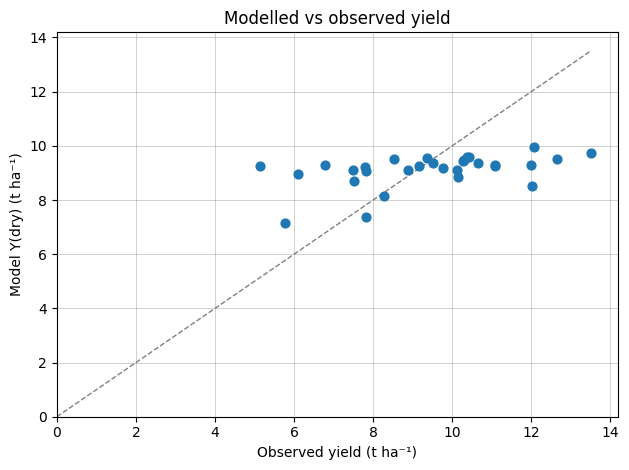

In [94]:
plot_yield_scatter(best_seasonal, get_yield(LOCATION, "grain", "A", "N3"))

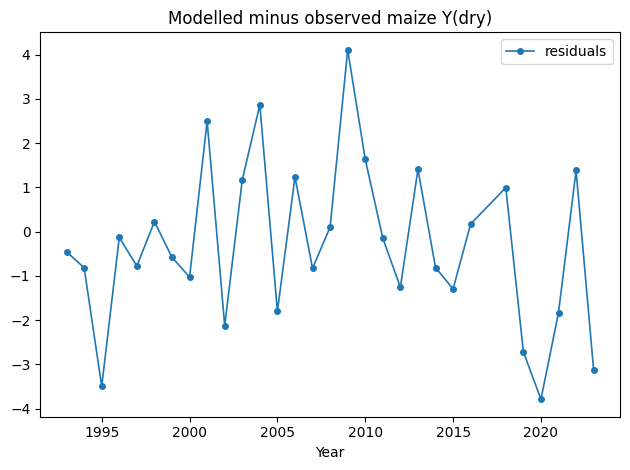

In [95]:
plot_yield_timeseries_residuals(best_seasonal, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)")

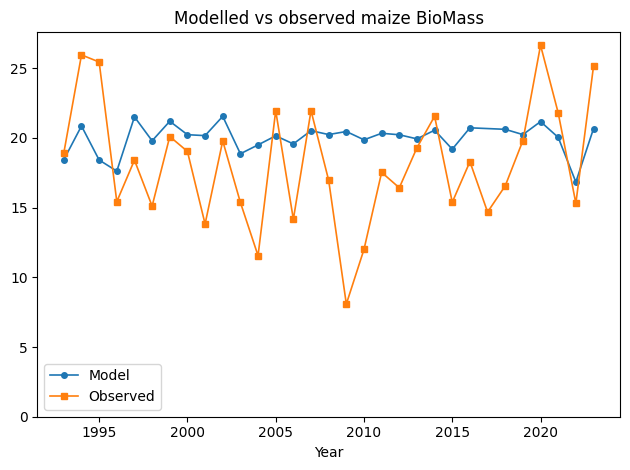

In [96]:
plot_yield_timeseries_comparison(best_seasonal, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass")

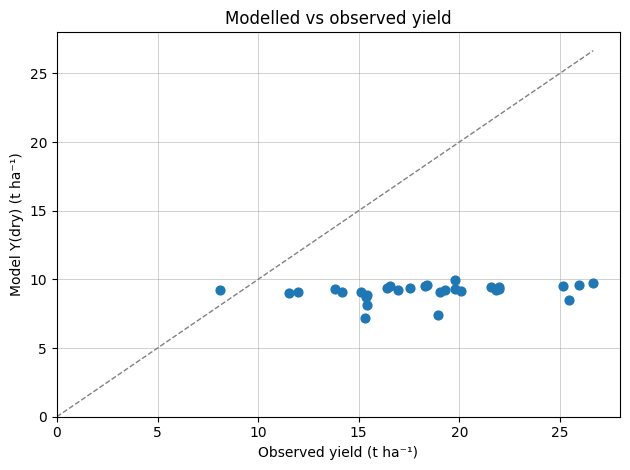

In [97]:
plot_yield_scatter(best_seasonal, get_yield(LOCATION, "biomass", "A", "N3"))